In [1]:
import numpy as np
import cv2
import os
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU') 

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [10]:
!pip install Pillow

In [11]:
from PIL import Image
img = Image.open(r'C:\Users\clair\Desktop\work\AI2down2\asl_dataset\2\hand1_2_bot_seg_2_cropped.jpeg')
print(img.size)

(400, 400)


In [13]:
from sklearn.model_selection import train_test_split
import shutil
#訓練集與測試集分割
# 定義原始數據集的路徑
original_dataset_dir = r'C:\Users\clair\Desktop\work\AI2down2\asl_dataset'

# 定義新的目錄結構
base_dir = r'C:\Users\clair\Desktop\work\AI2down2\base'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
train_categories = ['0','1','2','3','4','5','6','7','8','9','a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z']  # 訓練集中的類別
test_categories = ['0','1','2','3','4','5','6','7','8','9','a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z']   # 測試集中的類別

# 建立新的目錄
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# 將數據集劃分為訓練集和測試集
for category in train_categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)
    category_dir = os.path.join(original_dataset_dir, category)
    image_files = [f for f in os.listdir(category_dir) if os.path.isfile(os.path.join(category_dir, f))]
    train_images, test_images = train_test_split(image_files, test_size=0.2, random_state=42)

    # 將圖片複製到新的目錄
    for image in train_images:
        shutil.copy(os.path.join(category_dir, image), os.path.join(train_dir, category, image))
    for image in test_images:
        shutil.copy(os.path.join(category_dir, image), os.path.join(test_dir, category, image))


In [14]:
np.random.seed(1)

label_names=['0','1','2','3','4','5','6','7','8','9','a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z']

def load_data_from_folders(data_dir,label_names):
  images=[]
  labels=[]
  for label_id,label in enumerate(label_names):
    folder_path=os.path.join(data_dir,label)
    for file_name in os.listdir(folder_path):
      file_path=os.path.join(folder_path,file_name)
      img=cv2.imread(file_path)
      img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
      images.append(img)
      labels.append(label_id)
  return np.array(images),np.array(labels)

In [15]:
train_data_dir=r'C:\Users\clair\Desktop\work\AI2down2\base\train'
X_train,Y_train=load_data_from_folders(train_data_dir,label_names)

test_data_dir=r'C:\Users\clair\Desktop\work\AI2down2\base\test'
X_test,Y_test=load_data_from_folders(test_data_dir,label_names)

In [16]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0
Y_train=to_categorical(Y_train,num_classes=len(label_names))
Y_test=to_categorical(Y_test,num_classes=len(label_names))

In [ ]:
model=Sequential([
    Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(400,400,3)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(36,activation='softmax')
])

In [41]:
from keras.preprocessing.image import ImageDataGenerator
datagen=ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [42]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(datagen.flow(X_train,Y_train,batch_size=32),validation_data=(X_test,Y_test),epochs=300,verbose=1)
model.save('categorical_model.h5')
loss,accuracy=model.evaluate(X_test,Y_test)
print(f"Accuracy:{accuracy}")

Epoch 1/300
63/63 [==============================] - 208s 3s/step - loss: 5.5741 - accuracy: 0.0403 - val_loss: 3.5654 - val_accuracy: 0.0875
Epoch 2/300
63/63 [==============================] - 206s 3s/step - loss: 3.2461 - accuracy: 0.1019 - val_loss: 2.4790 - val_accuracy: 0.4195
Epoch 3/300
63/63 [==============================] - 202s 3s/step - loss: 2.5882 - accuracy: 0.2306 - val_loss: 1.7991 - val_accuracy: 0.4592
Epoch 4/300
63/63 [==============================] - 204s 3s/step - loss: 2.1773 - accuracy: 0.3305 - val_loss: 1.7023 - val_accuracy: 0.4374
Epoch 5/300
63/63 [==============================] - 199s 3s/step - loss: 1.9091 - accuracy: 0.3912 - val_loss: 1.4522 - val_accuracy: 0.5626
Epoch 6/300
63/63 [==============================] - 199s 3s/step - loss: 1.7315 - accuracy: 0.4269 - val_loss: 1.2666 - val_accuracy: 0.6143
Epoch 7/300
63/63 [==============================] - 199s 3s/step - loss: 1.6125 - accuracy: 0.4677 - val_loss: 0.9755 - val_accuracy: 0.7078
Epoch 

c:\Users\clair\AppData\Local\anaconda3\envs\2024work2\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


16/16 [==============================] - 6s 390ms/step - loss: 0.1743 - accuracy: 0.9284
Accuracy:0.9284294247627258


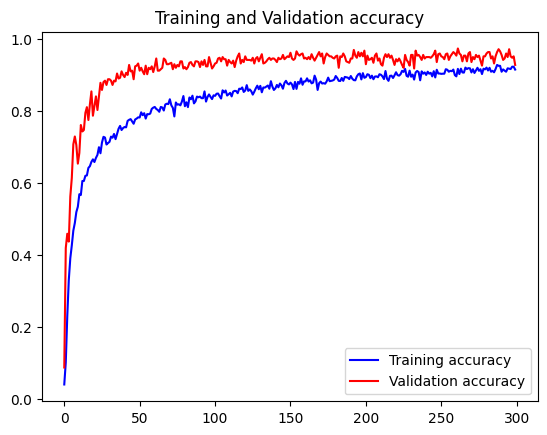

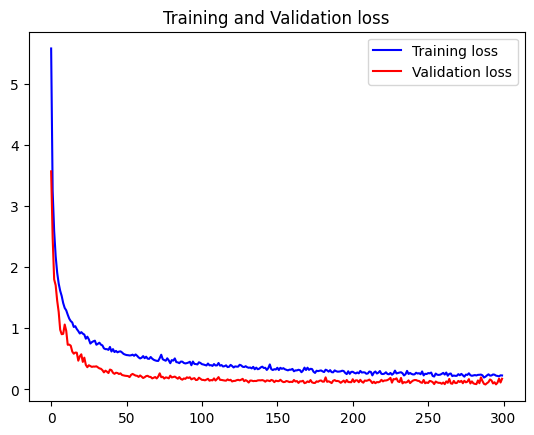

In [43]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc))

plt.plot(epochs,acc,'b',label='Training accuracy')
plt.plot(epochs,val_acc,'r',label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs,loss,'b',label='Training loss')
plt.plot(epochs,val_loss,'r',label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

In [3]:
from keras.models import load_model
import cv2
import numpy as np

model=load_model('categorical_model.h5')

image_path=r'C:\Users\clair\Desktop\AI2down2\pic\hand1_e_bot_seg_5_cropped.jpeg'
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

image=cv2.resize(image,(400,400))
image=image.astype('float32')/255.0
image=np.expand_dims(image,axis=0)

predictions=model.predict(image)
print(predictions)
predicted_class=np.argmax(predictions,axis=1)
a=str(predicted_class)
print(type(a))
print(f"Predicted class:{a}")

1/1 [==============================] - 1s 791ms/step
[[1.2880969e-10 2.4773682e-19 2.5977712e-22 9.9810097e-31 1.0535362e-25
  5.5374654e-27 2.5731703e-17 1.4956272e-21 4.1337715e-19 1.9221227e-22
  1.4066287e-17 5.0394950e-09 2.3180507e-17 2.2255741e-12 9.9999893e-01
  1.0261097e-06 4.8249843e-19 1.2099010e-24 7.6570647e-14 3.1130523e-15
  7.1657920e-20 2.2505518e-22 5.5041854e-10 1.1242793e-08 1.3308515e-15
  1.1535634e-22 9.5010178e-15 2.3719955e-20 2.1334545e-08 9.9977693e-10
  3.4622201e-11 7.4302403e-20 2.7027328e-19 5.0609744e-13 9.0317055e-27
  6.0944147e-21]]
<class 'str'>
Predicted class:[14]
